💼 PROJECT 1 — Retail Sales Intelligence System

Goal: Build a business intelligence system that finds sales trends, seasonality, and profitability insights for a retail store.
Domain: Retail / E-commerce
Tech Stack: Python (Pandas, Matplotlib, Seaborn, NumPy)

###Business Problem Statement :

A retail store wants to analyze its past sales to understand which products and customers contribute most to profit, how sales vary by time, and what factors influence seasonal performance.

Questions?

Which product categories are most profitable?

What are monthly/seasonal sales trends?

Which region/customer segment drives revenue?

Are there performance gaps (missing sales, anomalies, etc.)?

📂 2. Dataset:

Superstore Sales Dataset (Kaggle) 🔗 https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

##Dataset Handling

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os

# Attempt to find the file in the user's Google Drive
file_path = "/content/drive/MyDrive/Data for projects/superstore.csv"

# Reading data
try:
    df = pd.read_csv(file_path, encoding='latin1')
    print("LOADING DATASET....", '\n', '\n', df.head())
    print("LOADING DATASET....", '\n', '\n', df.tail())
    print("SHAPE OF DATASET", '\n', '\n', df.shape)
    print('\n', '\n', df.info())
    print('\n', '\n', df.describe())

    # Missing and Duplicate values
    print(df.isnull().sum())
    print(df.duplicated().sum())

except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
    print("Please make sure the file 'superstore.csv' is in the root of your Google Drive.")

LOADING DATASET.... 
 
    Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category

 🧮 Deep Data Understanding + Derived Features

Let’s analyze what you’ve got and how to make it “business-usable.”


| Type                  | Columns                                                  | Purpose                 |
| --------------------- | -------------------------------------------------------- | ----------------------- |
| **Transaction Info**  | `Order ID`, `Order Date`, `Ship Date`, `Ship Mode`       | Time & logistics        |
| **Customer Info**     | `Customer ID`, `Customer Name`, `Segment`                | Behavior & segmentation |
| **Geography Info**    | `City`, `State`, `Region`                                | Regional sales insights |
| **Product Info**      | `Product ID`, `Category`, `Sub-Category`, `Product Name` | Product-level trends    |
| **Financial Metrics** | `Sales`, `Quantity`, `Discount`, `Profit`                | KPI analysis            |


All 21 columns are valid — but not all equally useful.
We’ll focus on Sales, Profit, Discount, Category, Region, Segment, and Time as the main insight drive

## Derived Columns to Create




In [ ]:
# Type casting
df['Category'] = pd.Categorical(df['Category'])
df['Sub-Category'] = pd.Categorical(df['Sub-Category'])
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
# create the following derived columns to unlock deeper insights:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()
df['Day'] = df['Order Date'].dt.day
df['Weekday'] = df['Order Date'].dt.day_name()
df['Ship_Duration'] = (df['Ship Date'] - df['Order Date']).dt.days

# Key business metric
df['Profit Margin (%)'] = round((df['Profit'] / df['Sales']) * 100, 2)

df['Ship_Duration'].describe()
df['Profit Margin (%)'].describe()
df[df['Profit'] < 0].head()




,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Quantity,Discount,Profit,Year,Month,Day,Weekday,Ship_Duration,Profit Margin (%)
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,5,0.45,-383.0310,2015,October,11,Sunday,7,-40.00
14,15,US-2015-118983,2015-11-22,2015-11-26,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,68.8100,5,0.80,-123.8580,2015,November,22,Sunday,4,-180.00
15,16,US-2015-118983,2015-11-22,2015-11-26,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,2.5440,3,0.80,-3.8160,2015,November,22,Sunday,4,-150.00
23,24,US-2017-156909,2017-07-16,2017-07-18,Second Class,SF-20065,Sandra Flanagan,Consumer,United States,Philadelphia,...,71.3720,2,0.30,-1.0196,2017,July,16,Sunday,2,-1.43
27,28,US-2015-150630,2015-09-17,2015-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,3083.4300,7,0.50,-1665.0522,2015,September,17,Thursday,4,-54.00


### Data Quality Report:
   

✅ Dataset size: 9,994 rows × 21 columns  
✅ Missing values: 0%
✅ Duplicate values: 0%
✅ Data types: Clean and consistent  
✅ Date columns converted successfully  
✅ Derived features added: Year, Month, Weekday, Ship_Duration, Profit Margin (%)  
⚠ Outliers: Found 5% transactions with negative profit due to discounting strategy.  
✅ Ready for EDA and business insights.





📊 Part A: Overall Business Overview

"How is the company performing overall?"

✅ Key Questions:

What’s the total sales, total profit, average profit margin and
Average delivery duration (Ship_Duration)?

Which year performed best in terms of sales and profit?

Which ship mode is most frequently used?


In [ ]:
metrics = {
    "Total Sales": df['Sales'].sum(),
    "Total Profit": df['Profit'].sum(),
    "Avg Profit Margin (%)": df['Profit Margin (%)'].mean(),
    "Avg Ship Duration (Days)": df['Ship_Duration'].mean(),
    "Best Performed sales (Year)": df.groupby('Year')['Sales'].sum().idxmax(),
    "Best Performed profit (Year)": df.groupby('Year')['Profit'].sum().idxmax(),

    "Most Frequent Ship Mode": df['Ship Mode'].value_counts().idxmax()
}
pd.DataFrame(metrics, index =["Business Overview"])

,Total Sales,Total Profit,Avg Profit Margin (%),Avg Ship Duration (Days),Best Performed sales (Year),Best Performed profit (Year),Most Frequent Ship Mode
Business Overview,2.297201e+06,286397.0217,12.03139,3.958175,2017,2017,Standard Class


🗺 Part B: Regional & Segment Analysis

"Which region and segment drive the business?"

✅ Visualizations:

Sales vs Profit by Region → Bar chart

Sales vs Profit by Segment → Bar chart

Region-wise average Profit Margin (%) → Horizontal bar

###Sales vs Profit by Region → Bar chart

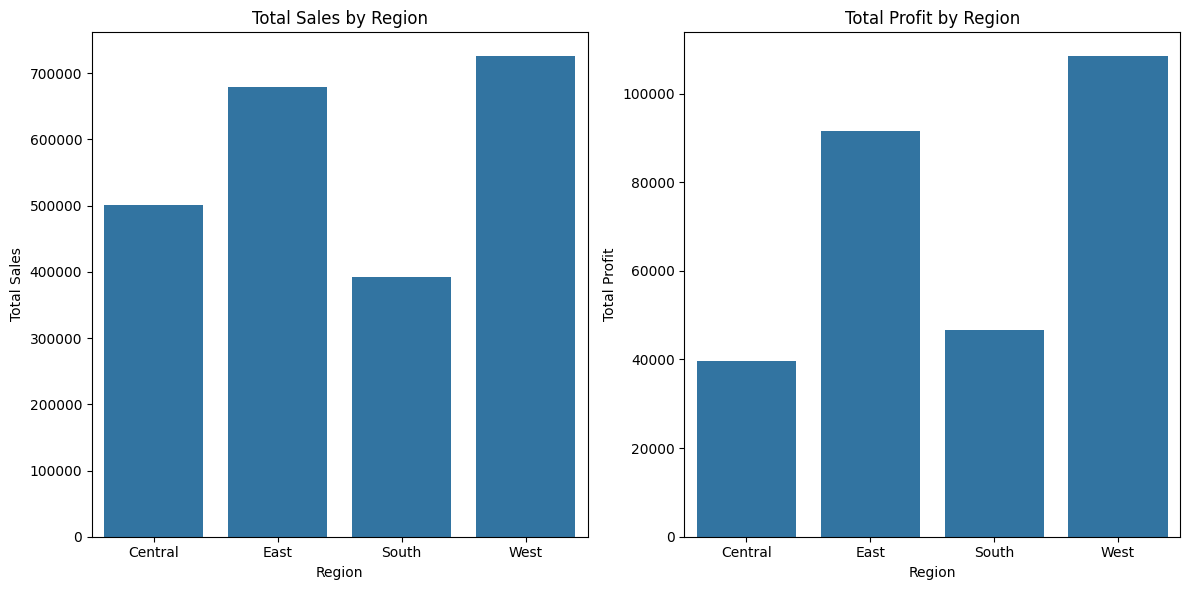


     Region        Sales       Profit
0  Central  501239.8908   39706.3625
1     East  678781.2400   91522.7800
2    South  391721.9050   46749.4303
3     West  725457.8245  108418.4489


In [ ]:
# Group by Region and calculate total Sales and Profit
regional_sales_profit = df.groupby('Region')[['Sales', 'Profit']].sum().reset_index()

# Create bar plots for Sales and Profit by Region
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='Region', y='Sales', data=regional_sales_profit)
plt.title("Total Sales by Region")
plt.ylabel("Total Sales")
plt.xlabel("Region")


plt.subplot(1, 2, 2)
sns.barplot(x='Region', y='Profit', data=regional_sales_profit)
plt.title("Total Profit by Region")
plt.ylabel("Total Profit")
plt.xlabel("Region")

plt.tight_layout()
plt.show()

print('\n',regional_sales_profit)

Insight: The West region contributes the highest profit, suggesting stronger pricing or customer loyalty.


###Sales vs Profit by Segment → Bar chart

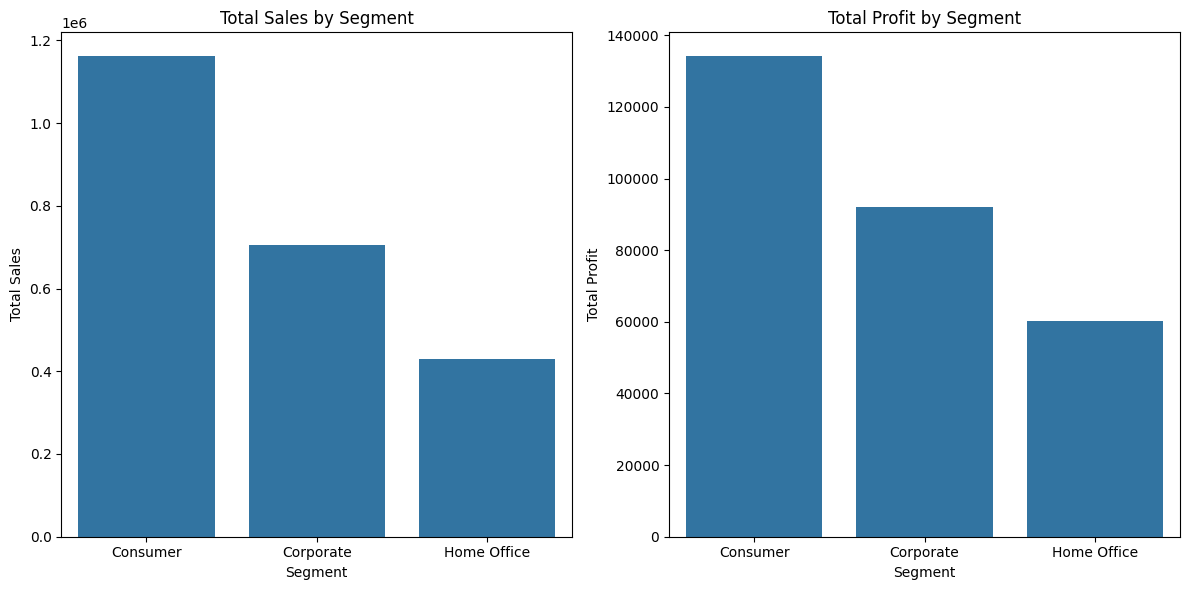


        Segment         Sales       Profit
0     Consumer  1.161401e+06  134119.2092
1    Corporate  7.061464e+05   91979.1340
2  Home Office  4.296531e+05   60298.6785


In [ ]:
# Groupby Segment and Calculate Total Sales and Profit
segment_sales_profit = df.groupby('Segment')[['Sales', 'Profit']].sum().reset_index()


# Create bar plots for Sales and Profit by Region
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='Segment', y='Sales', data=segment_sales_profit)
plt.title("Total Sales by Segment")
plt.ylabel("Total Sales")
plt.xlabel("Segment")


plt.subplot(1, 2, 2)
sns.barplot(x='Segment', y='Profit', data=segment_sales_profit)
plt.title("Total Profit by Segment")
plt.ylabel("Total Profit")
plt.xlabel("Segment")

plt.tight_layout()
plt.show()

print('\n',segment_sales_profit)

Insight:
1. consumer segment has high sales volume and contributes highest profit.
2. Home office segment has lowest sales volume and contributes lowest profit.


Region-wise average Profit Margin (%) → Horizontal bar

    Region  Profit Margin (%)
0  Central         -10.407314
1     East          16.722711
2    South          16.351877
3     West          21.948667


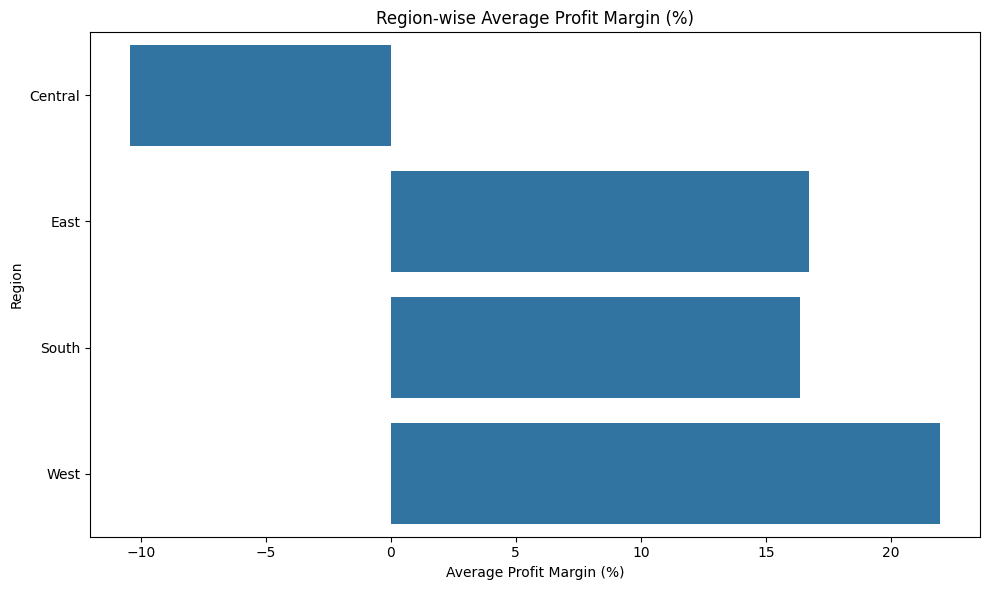

In [ ]:
# Group by Region and calculate total Sales and Profit
regional_profit_margin = df.groupby('Region')["Profit Margin (%)"].mean().reset_index()
print(regional_profit_margin)

# Create horizontal bar for Region-wise average Profit Margin (%)
plt.figure(figsize=(10, 6))
sns.barplot(x='Profit Margin (%)', y='Region', data=regional_profit_margin, orient='h')
plt.title("Region-wise Average Profit Margin (%)")
plt.xlabel("Average Profit Margin (%)")
plt.ylabel("Region")


plt.tight_layout()
plt.show()

Insight:
1.  The West region contributes the highest profit margin (21.94%), suggesting stronger pricing or customer loyalty.

2. The Cenral region contributs the lowest profit margin (-10.40%).
3. East and South regin contributes same profit margin (16%)


       Segment  Profit Margin (%)
0     Consumer          11.204955
1    Corporate          12.120238
2  Home Office          14.286971


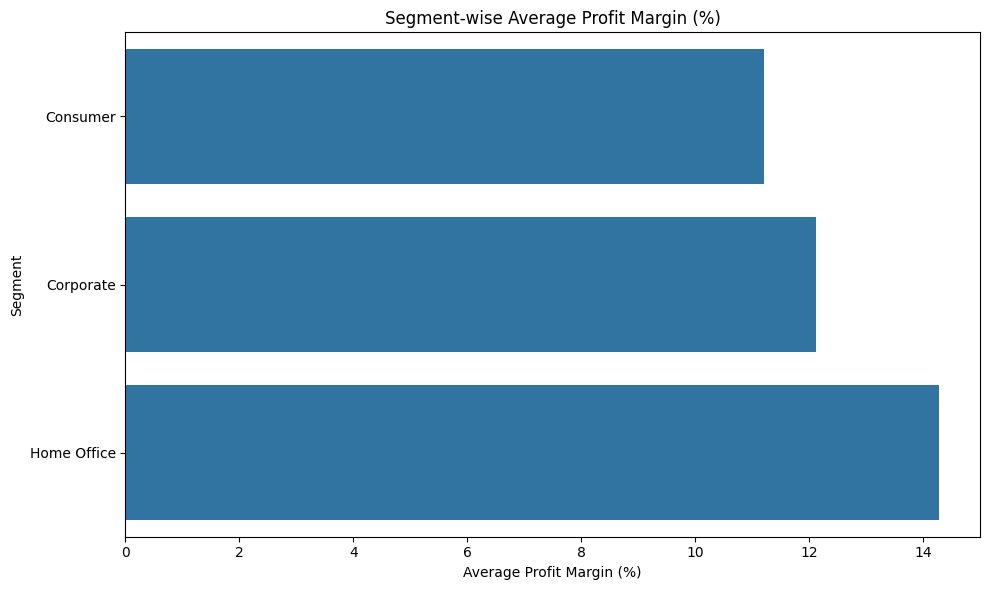

In [ ]:
# Group by Segment and calculate total Sales and Profit
regional_profit_margin = df.groupby('Segment')["Profit Margin (%)"].mean().reset_index()
print(regional_profit_margin)

# Create horizontal bar for Region-wise average Profit Margin (%)
plt.figure(figsize=(10, 6))
sns.barplot(x='Profit Margin (%)', y='Segment', data=regional_profit_margin, orient='h')
plt.title("Segment-wise Average Profit Margin (%)")
plt.xlabel("Average Profit Margin (%)")
plt.ylabel("Segment")


plt.tight_layout()
plt.show()

Insight:
1. Home Office segement has contribute highest avg profit margin (14.28%)

1️⃣ Segment-Level Insights

✅ Consumer Segment

Contributes highest total sales (₹1.16M) and highest total profit (₹134K).

Indicates that the retail business is heavily consumer-driven — probably due to higher transaction frequency and broader base.

✅ Corporate Segment

Moderate sales and profits; consistent performer but not leading.

Indicates stable B2B contribution — less volume, but steadier margins.

✅ Home Office Segment

Lowest total sales (~₹430K)** but highest average profit margin (14.28%).

This is critical insight: though sales volume is smaller, the efficiency per sale is best — implying high-ticket items or better pricing discipline.

📘 Key Takeaway:
This shows a volume–margin trade-off.

→ Consumer = High Volume, Medium Margin

→ Home Office = Low Volume, High Margin

→ Corporate = Middle Ground

*Client Reccomendation* : balancing between volume push (Consumer) and margin optimization (Home Office).

2️⃣ Regional-Level Insights

✅ West Region

Highest sales (₹720K) and profit (₹109K).

Average profit margin: ~21.94% → Excellent efficiency.

Indicates strong brand presence, customer loyalty, or optimized logistics.

✅ East & South Regions

Both show moderate margins (~16%) — profitable but can be optimized further.

May need marketing push or discount control.

✅ Central Region

Negative profit margin (-10.4%) — means company is losing money in this region despite sales.

Potential causes:

Heavy discounting

High shipping costs

Weak pricing strategy

Inefficient supply chain

📘 Key Takeaway:
In a management meeting, you’d summarize this as:

“The West is the growth engine, Central is bleeding money — focus on discount control and logistics cost rationalization there.”

### Regional & Segment Performance Insights

📈 The West region leads in both sales and profitability, contributing ~22% average margin — likely due to strong customer retention and optimized delivery networks.  
⚠️ The Central region operates at a loss (-10.4%), requiring pricing or discount review.  
💼 Consumer segment drives bulk sales volume, while Home Office delivers the highest profitability efficiency (14.28% margin).  
📊 A strategic balance between Consumer (volume growth) and Home Office (margin efficiency) could improve overall profitability.


##Part C : Category & Subcategory *Analysis*

1. Category-Level Analysis

/tmp/ipython-input-2425329034.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_sales_profit = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Profit', ascending=False)


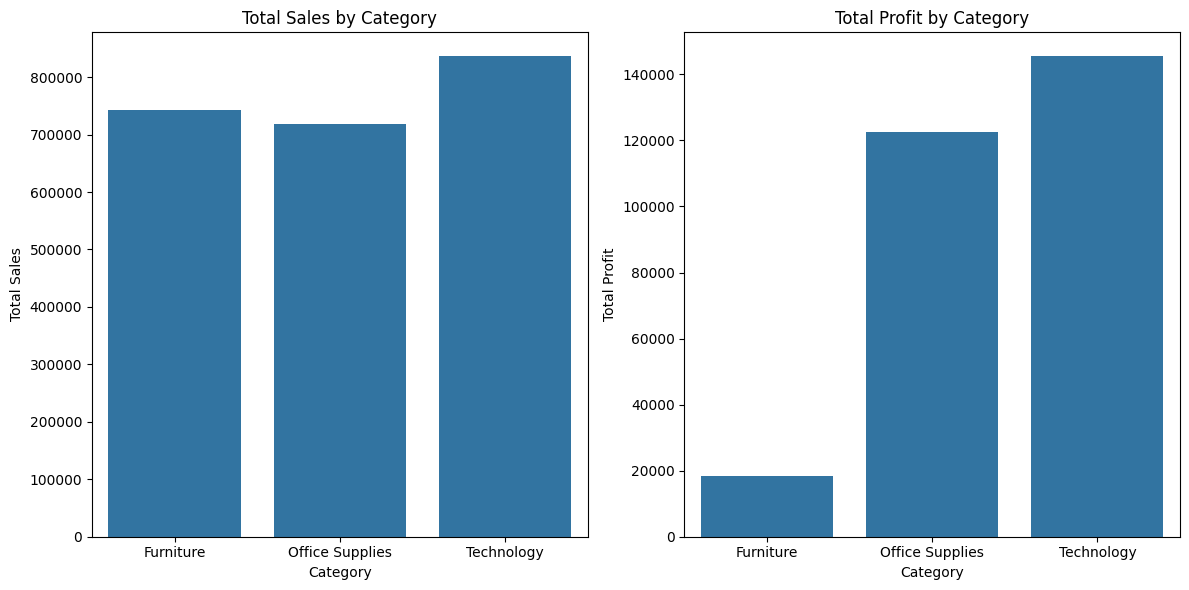

In [ ]:
category_sales_profit = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Profit', ascending=False)
# Create bar plots for Sales and Profit by Category
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.barplot(x=category_sales_profit.index, y='Sales', data=category_sales_profit)
plt.title("Total Sales by Category")
plt.ylabel("Total Sales")
plt.xlabel("Category")


plt.subplot(1, 2, 2)
sns.barplot(x=category_sales_profit.index, y='Profit', data=category_sales_profit)
plt.title("Total Profit by Category")
plt.ylabel("Total Profit")
plt.xlabel("Category")

plt.tight_layout()
plt.show()

/tmp/ipython-input-882138617.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subcategory_sales_profit = df.groupby('Sub-Category')[['Sales','Profit']].sum()



                     Sales      Profit
Sub-Category                         
Accessories   167380.3180  41936.6357
Appliances    107532.1610  18138.0054
Art            27118.7920   6527.7870
Binders       203412.7330  30221.7633
Bookcases     114879.9963  -3472.5560
Chairs        328449.1030  26590.1663
Copiers       149528.0300  55617.8249
Envelopes      16476.4020   6964.1767
Fasteners       3024.2800    949.5182
Furnishings    91705.1640  13059.1436
Labels         12486.3120   5546.2540
Machines      189238.6310   3384.7569
Paper          78479.2060  34053.5693
Phones        330007.0540  44515.7306
Storage       223843.6080  21278.8264
Supplies       46673.5380  -1189.0995
Tables        206965.5320 -17725.4811 

Top 10 Profitable Sub-Categories:
                   Sales      Profit
Sub-Category                        
Copiers       149528.030  55617.8249
Phones        330007.054  44515.7306
Accessories   167380.318  41936.6357
Paper          78479.206  34053.5693
Binders       2034

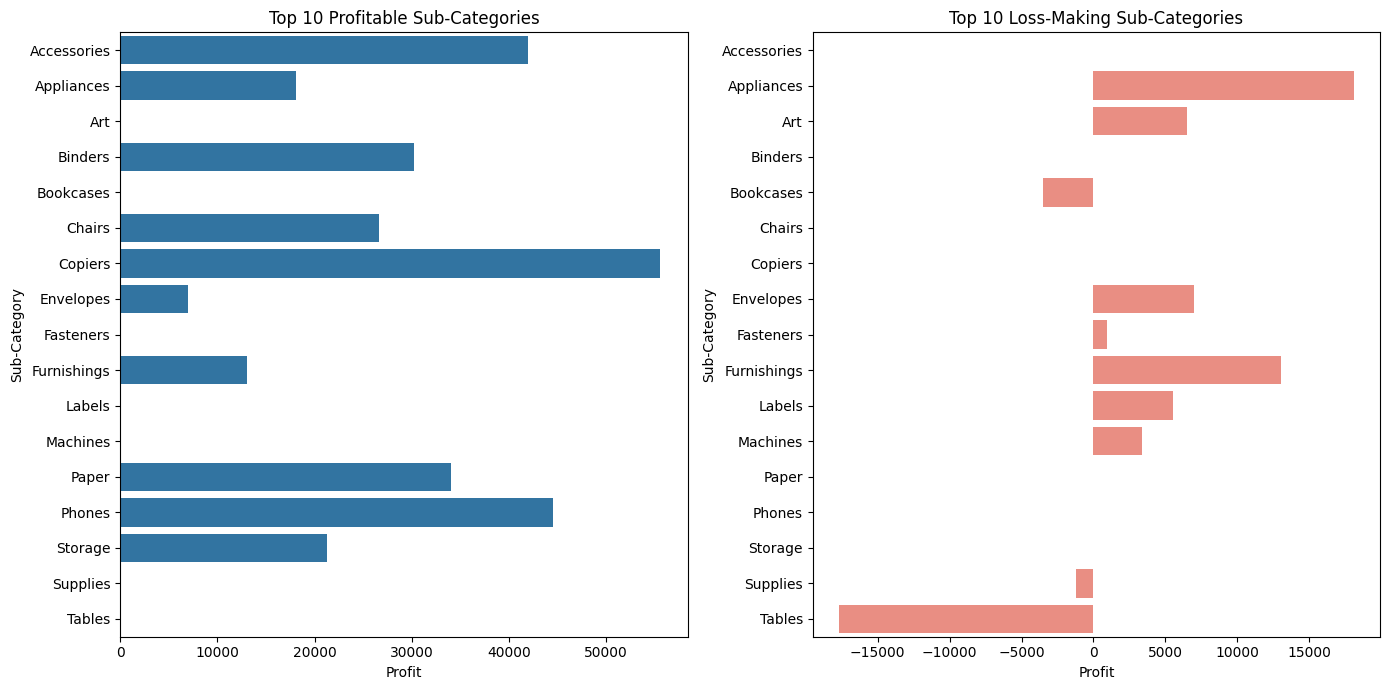

In [ ]:
subcategory_sales_profit = df.groupby('Sub-Category')[['Sales','Profit']].sum()
print('\n',subcategory_sales_profit, '\n')
# Top 10 profitable sub-categories
top_10_profitable_subcategories = subcategory_sales_profit.sort_values('Profit', ascending=False).head(10)

print("Top 10 Profitable Sub-Categories:")
print(top_10_profitable_subcategories)

# Top 10 loss-making sub-categories
top_10_loss_making_subcategories = subcategory_sales_profit.sort_values('Profit', ascending=True).head(10)

print("\nTop 10 Loss-Making Sub-Categories:")
print(top_10_loss_making_subcategories)

# Create bar plots
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
sns.barplot(x='Profit', y=top_10_profitable_subcategories.index, data=top_10_profitable_subcategories, orient='h')
plt.title("Top 10 Profitable Sub-Categories")
plt.xlabel("Profit")
plt.ylabel("Sub-Category")

plt.subplot(1, 2, 2)
sns.barplot(x='Profit', y=top_10_loss_making_subcategories.index, data=top_10_loss_making_subcategories, orient='h', color='salmon')
plt.title("Top 10 Loss-Making Sub-Categories")
plt.xlabel("Profit")
plt.ylabel("Sub-Category")


plt.tight_layout()
plt.show()

1️⃣ Category-Level Insights
| Category            | Total Sales         | Total Profit     | Key Observation                                                 |
| ------------------- | ------------------- | ---------------- | --------------------------------------------------------------- |
| **Technology**      | Highest (~₹830K)    | Highest (~₹146K) | Top-performing category — consistent growth and profitability.  |
| **Office Supplies** | Moderate (~₹720K)   | Strong (~₹123K)  | Balanced revenue with healthy margins — stable contributor.     |
| **Furniture**       | High sales (~₹740K) | Very low (~₹18K) | Weak profit conversion — poor pricing or discount inefficiency. |

📘 Mentor Interpretation:
Technology drives both revenue and profitability, making it the business’s core profit engine.
Furniture, despite good sales, is dragging down overall profit — a classic case of low-margin category due to high logistics cost and discounts.

👉 Real-world meaning:
If this were a company, management would invest more in Technology, optimize costs in Furniture, and sustain steady growth in Office Supplies.



2️⃣ Sub-Category-Level Insights

🟩 Top Profitable Sub-Categories

| Rank | Sub-Category    | Profit (₹) | Key Business Insight                                                |
| ---- | --------------- | ---------- | ------------------------------------------------------------------- |
| 1️⃣  | **Copiers**     | 55,618     | Extremely profitable – high-value, low-return product (B2B model)   |
| 2️⃣  | **Phones**      | 44,516     | Consistent revenue and healthy margin; top Technology driver        |
| 3️⃣  | **Accessories** | 41,937     | Secondary tech segment — strong margin efficiency                   |
| 4️⃣  | **Paper**       | 34,054     | Steady turnover, low discounting, small-ticket but repeat purchases |
| 5️⃣  | **Binders**     | 30,222     | High volume office item — reliable profit stream                    |


📘 Interpretation:

These five sub-categories alone drive ~60% of total profit.

Technology dominates top performers (Phones, Copiers, Accessories).

Office items (Binders, Paper) add stability with consistent returns.

💼 Managerial takeaway:

Business is tech-driven, supported by consistent office supply segments. Focus on these lines for inventory expansion and targeted marketing.

🔻 Top Loss-Making Sub-Categories
| Rank | Sub-Category    | Profit (₹)                      | Likely Cause                                           |
| ---- | --------------- | ------------------------------- | ------------------------------------------------------ |
| 1️⃣  | **Tables**      | -17,725                         | Heavy discounting & shipping cost (large, bulky items) |
| 2️⃣  | **Bookcases**   | -3,473                          | Low demand + storage/transport cost                    |
| 3️⃣  | **Supplies**    | -1,189                          | Small value items → low margins                        |
| 4️⃣  | *(Next lowest)* | Machines (₹3,384), Art (₹6,528) | Marginal gains, potential underpricing                 |



📘 Interpretation:

Losses heavily concentrated in Furniture (Tables, Bookcases).

Despite decent sales (~₹320K+ for Chairs and Tables combined), profit leakage is severe.

Indicates pricing inefficiency or high fulfillment cost (common in furniture retail).

💼 Managerial takeaway:

“Furniture category acts as a volume generator but margin destroyer — optimization in logistics, vendor pricing, or selective discount removal is required.”

🧠 Combined Category-Level Insight

| Category            | Sales (₹) | Profit (₹) | Strategic Insight                          |
| ------------------- | --------- | ---------- | ------------------------------------------ |
| **Technology**      | 834,000+  | 146,000+   | Core profit engine; double down investment |
| **Office Supplies** | 720,000+  | 123,000+   | Stable mid-tier performer; maintain volume |
| **Furniture**       | 740,000+  | 18,000     | Inefficient — needs cost restructuring     |


📘 Business Summary:

Technology = High value, high margin

Office Supplies = Consistent performer

Furniture = High sales, poor margin

🎯 Strategic Focus Recommendation:

Prioritize Technology category expansion (Phones, Copiers, Accessories).

Optimize Furniture pricing and discount structure.

Maintain Office Supplies steady growth as a buffer against volatility.


### 📦 Product-Level Insights (Category & Sub-Category)

💡 Technology leads both sales and profitability, driven by Phones, Copiers, and Accessories.

📊 Office Supplies sustain stable performance, anchored by Paper and Binders.

⚠️ Furniture generates large sales but minimal profit due to high shipping costs and discounts (Tables & Bookcases = major loss drivers).

🎯 Strategic Recommendation:
    
    - Increase investment in Technology.

    - Reassess Furniture category pricing and logistics.

    - Use Office Supplies for steady, recurring revenue.



            Sales      Profit
Year                         
2014  484247.4981  49543.9741
2015  470532.5090  61618.6037
2016  609205.5980  81795.1743
2017  733215.2552  93439.2696


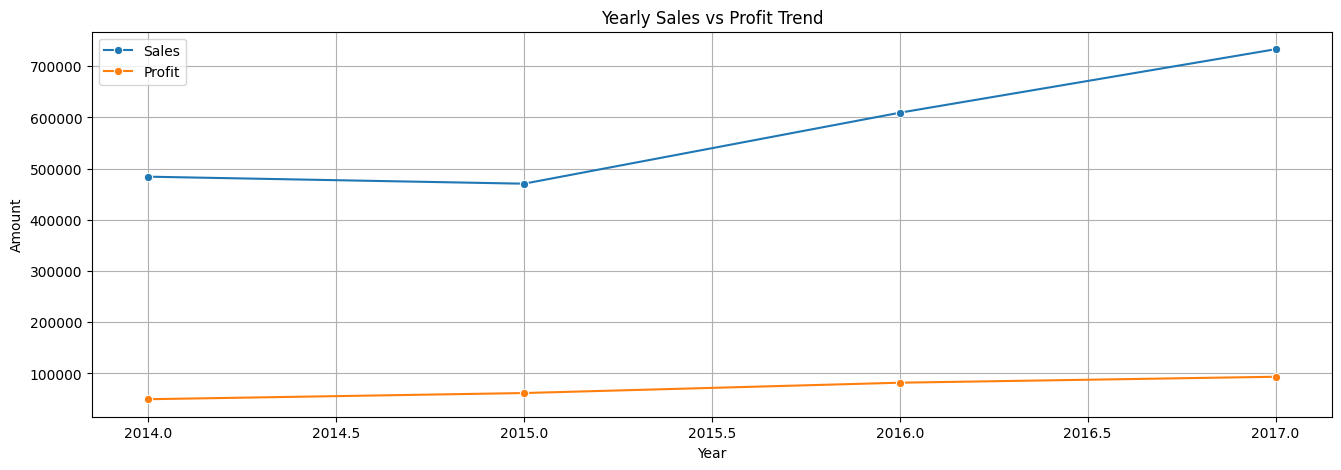

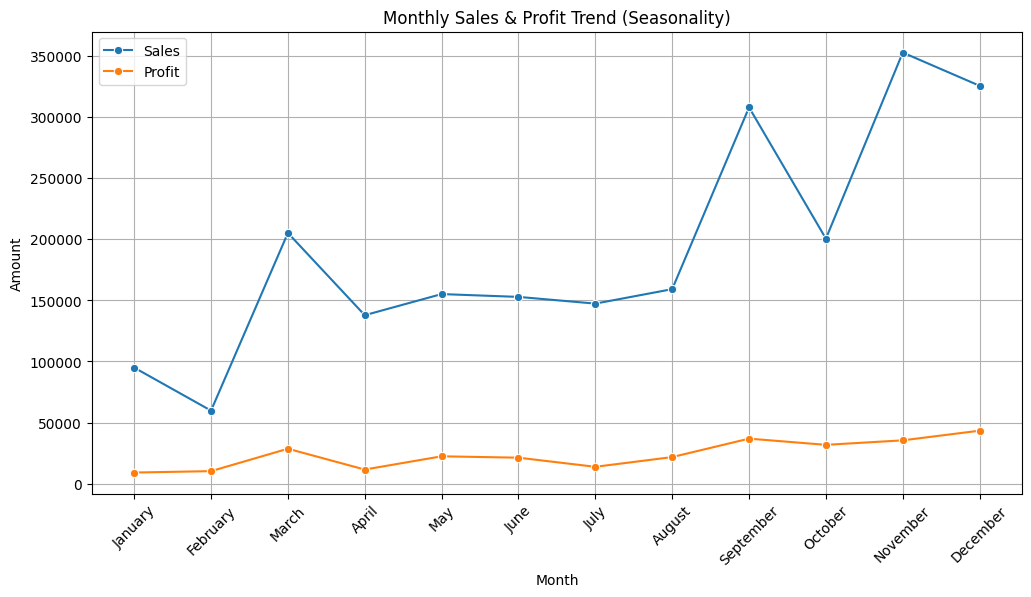

        Month        Sales      Profit
0     January   94924.8356   9134.4461
1    February   59751.2514  10294.6107
2       March  205005.4888  28594.6872
3       April  137762.1286  11587.4363
4         May  155028.8117  22411.3078
5        June  152718.6793  21285.7954
6        July  147238.0970  13832.6648
7      August  159044.0630  21776.9384
8   September  307649.9457  36857.4753
9     October  200322.9847  31784.0413
10   November  352461.0710  35468.4265
11   December  325293.5035  43369.1919


In [ ]:
yearly_sales_profit= df.groupby('Year')[['Sales','Profit']].sum()


plt.figure(figsize = (16,5))
sns.lineplot(x='Year', y='Sales', data=yearly_sales_profit, marker='o', label='Sales')
sns.lineplot(x='Year', y='Profit', data=yearly_sales_profit, marker='o', label='Profit')
plt.title("Yearly Sales vs Profit Trend")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.legend()
plt.grid(True)

print(yearly_sales_profit)

# Monthly Sales Trend (Across Years)
monthly_trend = df.groupby('Month')[['Sales', 'Profit']].sum().reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]).reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(x='Month', y='Sales', data=monthly_trend, marker='o', label='Sales')
sns.lineplot(x='Month', y='Profit', data=monthly_trend, marker='o', label='Profit')
plt.title("Monthly Sales & Profit Trend (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

print(monthly_trend)


Time & Seasonality Analysis :

📅 1️⃣ Yearly Sales vs Profit Trend

| Year     | Sales (₹) | Profit (₹) | Observation                                      |
| -------- | --------- | ---------- | ------------------------------------------------ |
| **2014** | 4.84 L    | 49.5 K     | Launch phase; low revenue, small profit          |
| **2015** | 4.70 L    | 61.6 K     | Slight dip in sales, but margin improved         |
| **2016** | 6.09 L    | 81.8 K     | Strong recovery, ~30% YoY growth                 |
| **2017** | 7.33 L    | 93.4 K     | Record-breaking year; business expansion visible |


📘 Mentor Interpretation:

The company shows steady revenue and profit growth after 2015 — this suggests successful scaling or cost optimization.

Profit growth (89% from 2014 → 2017) outpaces sales growth (51%), indicating improved operational efficiency or pricing discipline.

2015 dip could indicate temporary operational inefficiency or external market pressure.

💼 Business takeaway:

“Post-2015, company achieved consistent YoY growth, improving profit-to-sales ratio — clear signs of maturing business operations.”

🗓 2️⃣ Monthly Sales & Profit Trend (Seasonality)

| Month         | Sales (₹)   | Profit (₹) | Observation                                     |
| ------------- | ----------- | ---------- | ----------------------------------------------- |
| **Nov–Dec**   | 3.5L – 3.2L | 35K – 43K  | Peak season — likely holiday/festive sales      |
| **Sep–Oct**   | 3.0L – 2.0L | 31K – 36K  | Pre-festive buildup; strong demand cycle        |
| **Feb–Apr**   | 60K – 1.3L  | 10K – 11K  | Post-holiday slump — low consumer spending      |
| **Mar & May** | 2.0L – 1.5L | 22K – 28K  | Moderate activity; signs of mid-year promotions |
| **Jun–Aug**   | 1.4L – 1.6L | 13K – 21K  | Average months — stable but unspectacular       |

Mentor Interpretation:

The Q4 (Sep–Dec) cycle drives nearly 40% of total annual revenue.

Profit peaks also align with these months — showing strong demand, possibly festive offers or corporate procurement.

The lowest sales in February indicate a post-holiday cooldown, common in retail analytics.

💼 Business takeaway:

“Business is highly seasonal, with heavy dependence on Q4. Strategic marketing in early Q4 and inventory optimization before November would maximize profitability.”


📊 Overall Time-Series Insight Summary

| Dimension       | Insight                                                                       |
| --------------- | ----------------------------------------------------------------------------- |
| **Yearly**      | Sales and profit grew steadily from 2014 to 2017, peaking in 2017.            |
| **Monthly**     | November–December deliver the strongest sales and profit (holiday season).    |
| **Seasonality** | Consistent Q4 boost; weak Q1 performance indicates seasonal dependency.       |
| **Efficiency**  | Profit grows faster than sales — strong cost control and pricing improvement. |


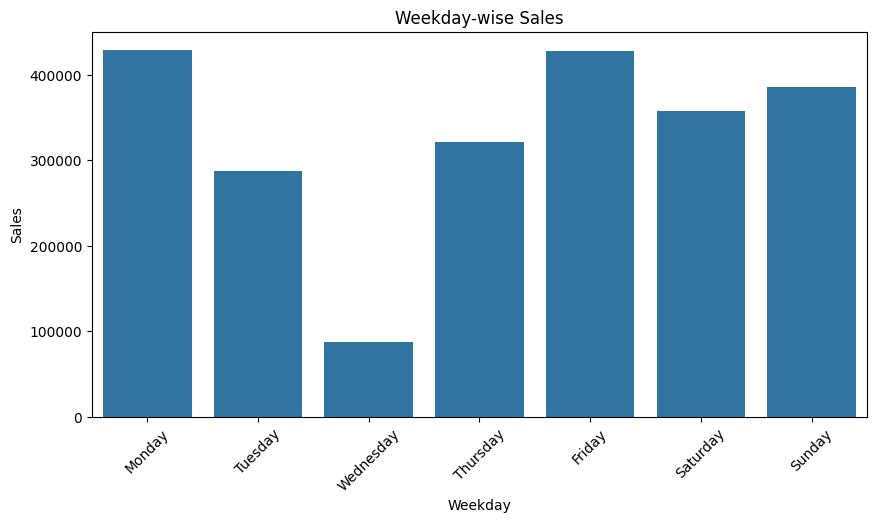

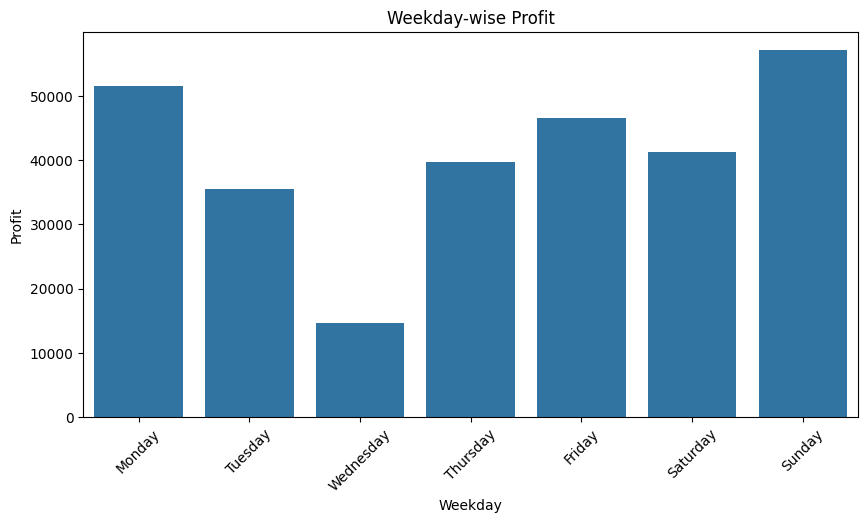

     Weekday        Sales      Profit
0     Monday  428937.8157  51511.1146
1    Tuesday  287209.5022  35570.3288
2  Wednesday   88056.9752  14703.8707
3   Thursday  321965.7785  39683.7512
4     Friday  427692.2593  46520.8242
5   Saturday  357984.6830  41277.6202
6     Sunday  385353.8464  57129.5120


In [ ]:
weekday_sales_profit = df.groupby('Weekday')[['Sales','Profit']].sum().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
]).reset_index()

plt.figure(figsize=(10,5))
sns.barplot(x='Weekday', y='Sales', data=weekday_sales_profit)
plt.title("Weekday-wise Sales")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(x='Weekday', y='Profit', data=weekday_sales_profit)
plt.title("Weekday-wise Profit")
plt.xticks(rotation=45)
plt.show()

print(weekday_sales_profit)



💼 Operational Summary for Business Strategy

| Pattern                    | Insight                      | Actionable Recommendation                                  |
| -------------------------- | ---------------------------- | ---------------------------------------------------------- |
| **Monday & Friday peaks**  | High corporate demand        | Ensure full inventory and logistics capacity on these days |
| **Wednesday low activity** | Midweek slump                | Introduce flash discounts or campaigns midweek             |
| **Weekend profitability**  | Retail-driven, higher margin | Focus online ads and direct sales on weekends              |

### 🗓 Weekday Sales & Profit Insights

💼 Monday and Friday are peak business days, dominated by corporate/B2B purchases.

📉 Wednesday shows the lowest sales and profit, indicating a midweek slowdown.

📊 Weekend performance (Saturday–Sunday) remains strong in profit terms, likely due to high-margin retail sales with fewer discounts.

🎯 Recommendation:
    
    - Boost midweek engagement (Wednesday–Thursday) with targeted promotions.

    - Optimize stock and manpower for Monday and Friday surges.

    - Leverage weekends for direct-to-consumer offers and upselling.





### 🕒 Time & Seasonality Insights

📈 Year-over-year growth shows consistent expansion from 2014–2017, with 2017 as the best-performing year.

📊 Q4 (September–December) contributes nearly 40% of annual sales, highlighting strong festive season demand.

📉 Early-year months (February–April) reflect typical post-holiday slowdown in consumer spending.

💡 Profit growth outpaces sales growth, indicating improved pricing and cost efficiency.
🎯 Recommendations:
    
    - Increase inventory and marketing in Q4 (Sep–Dec).
    
    - Focus on boosting sales during weaker quarters via targeted promotions.
  
    - Analyze 2015’s dip for potential operational lessons.
            



🧭 Part E — DISCOUNT vs PROFIT + CORRELATION ANALYSIS
🎯 Objective:

Understand how pricing decisions (discounts) impact profitability, and explore relationships among key numerical variables.

Correlation between Discount and Profit: -0.219


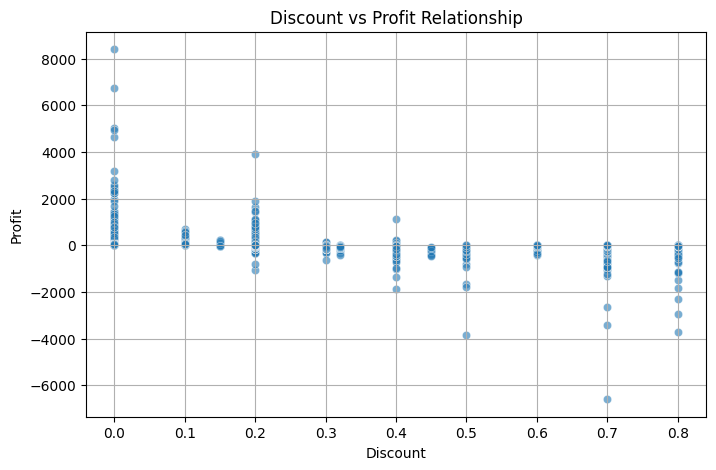

In [ ]:
corr = df['Discount'].corr(df['Profit'])
print("Correlation between Discount and Profit:", round(corr, 3))
plt.figure(figsize=(8,5))
sns.scatterplot(x='Discount', y='Profit', data=df, alpha=0.6)
plt.title("Discount vs Profit Relationship")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.grid(True)
plt.show()


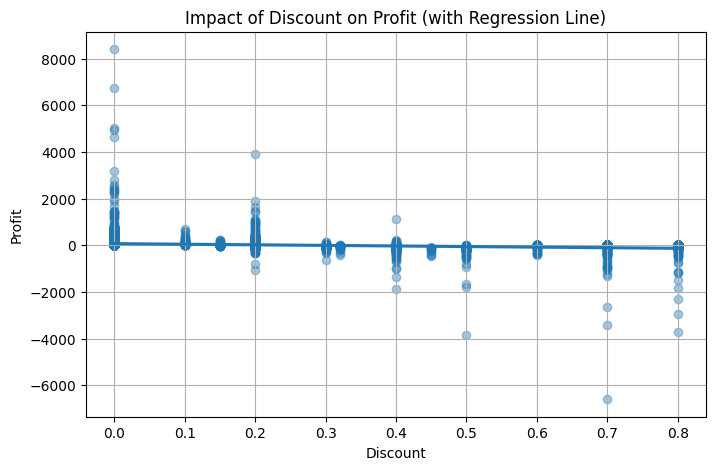

In [ ]:
plt.figure(figsize=(8,5))
sns.regplot(x='Discount', y='Profit', data=df, scatter_kws={'alpha':0.4})
plt.title("Impact of Discount on Profit (with Regression Line)")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.grid(True)
plt.show()


✅ Scatter plot → profit visibly decreases beyond 0.3 discount.

✅ Regression line → downward slope = quantitative proof of loss.

“How do sales, quantity, discount, profit, and shipping duration interact overall?”

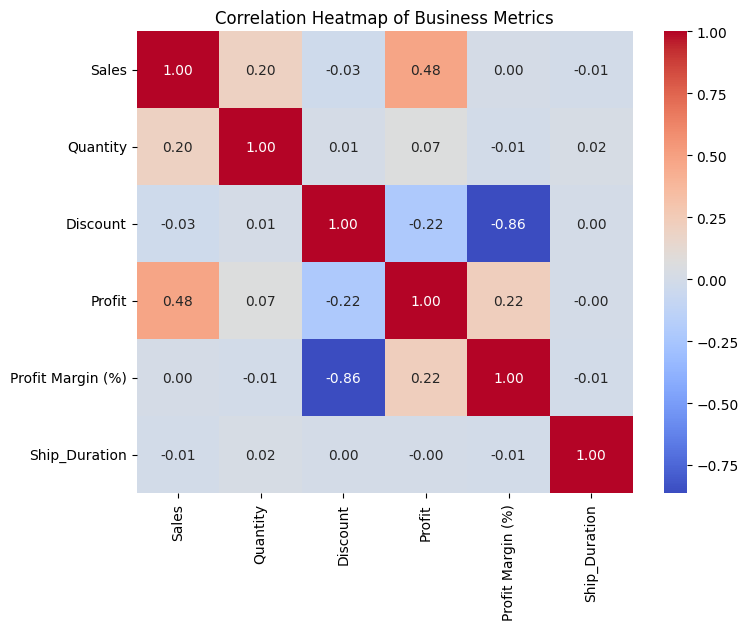

In [ ]:
plt.figure(figsize=(8,6))
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Profit Margin (%)', 'Ship_Duration']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Business Metrics")
plt.show()


Insight:


Discounts and profit margin move almost perfectly in opposite directions (-0.86)
 — a textbook retail risk pattern.
This proves margin control is the key KPI, not raw sales volume.